# Waste2Cash — Modèle de Prédiction d'Écoulement des Invendus

Ce notebook construit et entraîne l'IA de Waste2Cash. Deux briques :

1. **Modèle d'écoulement (par lot)** : prédit, pour un lot donné (catégorie, DLC, distance, etc.),
   - la probabilité qu'il soit effectivement écoulé (`was_sold`),
   - le temps estimé avant écoulement (`time_to_sell_hours`).
2. **Modèle de prévision de volume (par catégorie, horizon 6 mois)** : prévoit le volume d'invendus
   attendu par catégorie de produit pour piloter les partenariats et la capacité de collecte à l'avance.

> Environnement offline : nous utilisons `scikit-learn` (RandomForest / GradientBoosting) plutôt que
> XGBoost/Prophet. En production, ces modèles peuvent être remplacés par XGBoost et Prophet pour de
> meilleures performances — l'architecture et le pipeline de features restent identiques.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              mean_absolute_error, r2_score)

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (9, 5)

## 1. Chargement des données

In [17]:
df = pd.read_csv("waste2cash_dataset.csv", parse_dates=["collection_datetime"])
print(df.shape)
df.head()

(15000, 26)


,id,product_category,product_subcategory,quantity_kg,unit_price_initial,days_until_expiry,storage_condition,packaging_type,collection_datetime,day_of_week,month_of_year,season,is_holiday,pickup_store_id,pickup_city,distance_to_partner_km,partner_id_destination,partner_storage_capacity,partner_typical_demand,weather_temperature,rainfall_mm,time_to_sell_hours,was_sold,final_discount_rate,wastage_reason,partner_satisfaction_score
0,1,Boulangerie,Viennoiserie,78.5,1.33,1,Ambiante,Plastique,2024-07-23 22:00:00,Tuesday,7,Pluies,0,S017,Abidjan,14.3,P020,899,718.6,32.0,12.0,11.8,1,31.3,NaN,4
1,2,Produits Laitiers,Fromage,14.8,2.28,4,Frais,Vrac,2025-02-03 14:00:00,Monday,2,Sèche,0,S016,Bouaké,37.0,P016,185,234.8,25.1,4.5,22.2,1,46.7,NaN,4
2,3,Fruits & Légumes,Légumes racines,30.7,1.53,3,Frais,Vrac,2024-03-26 03:00:00,Tuesday,3,Sèche,1,S024,San-Pédro,8.2,P004,1544,474.0,31.4,9.9,16.2,1,31.4,NaN,4
3,4,Fruits & Légumes,Légumes racines,36.9,1.44,2,Frais,Carton,2024-02-01 20:00:00,Thursday,2,Sèche,0,S037,Abidjan,37.0,P006,133,127.2,31.5,15.0,14.5,1,71.8,NaN,2
4,5,Viande & Poisson,Volaille,21.5,5.07,1,Frais,Plastique,2024-11-24 16:00:00,Sunday,11,Sèche,0,S029,Yamoussoukro,44.0,P005,1669,44.8,27.8,4.2,13.4,1,79.4,NaN,4


In [18]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          15000 non-null  int64         
 1   product_category            15000 non-null  object        
 2   product_subcategory         15000 non-null  object        
 3   quantity_kg                 15000 non-null  float64       
 4   unit_price_initial          15000 non-null  float64       
 5   days_until_expiry           15000 non-null  int64         
 6   storage_condition           15000 non-null  object        
 7   packaging_type              15000 non-null  object        
 8   collection_datetime         15000 non-null  datetime64[ns]
 9   day_of_week                 15000 non-null  object        
 10  month_of_year               15000 non-null  int64         
 11  season                      15000 non-null  object    

,0
id,0
product_category,0
product_subcategory,0
quantity_kg,0
unit_price_initial,0
days_until_expiry,0
storage_condition,0
packaging_type,0
collection_datetime,0
day_of_week,0


## 2. Feature engineering

On dérive quelques variables temporelles supplémentaires et on prépare les colonnes catégorielles / numériques.

In [19]:
df["month_of_year"] = df["collection_datetime"].dt.month
df["day_of_week"] = df["collection_datetime"].dt.day_name()
df["hour_of_day"] = df["collection_datetime"].dt.hour
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# Ratio DLC restante vs temps déjà écoulé - proxy d'urgence
df["urgency_ratio"] = df["days_until_expiry"] / (df["days_until_expiry"].mean() + 1)

CATEGORICAL_FEATURES = [
    "product_category", "product_subcategory", "storage_condition", "packaging_type",
    "pickup_city", "day_of_week", "season",
]
NUMERIC_FEATURES = [
    "quantity_kg", "unit_price_initial", "days_until_expiry", "is_holiday",
    "distance_to_partner_km", "partner_storage_capacity", "partner_typical_demand",
    "weather_temperature", "rainfall_mm", "month_of_year", "hour_of_day",
    "is_weekend", "urgency_ratio",
]

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES
df[FEATURES].head()

,product_category,product_subcategory,storage_condition,packaging_type,pickup_city,day_of_week,season,quantity_kg,unit_price_initial,days_until_expiry,is_holiday,distance_to_partner_km,partner_storage_capacity,partner_typical_demand,weather_temperature,rainfall_mm,month_of_year,hour_of_day,is_weekend,urgency_ratio
0,Boulangerie,Viennoiserie,Ambiante,Plastique,Abidjan,Tuesday,Pluies,78.5,1.33,1,0,14.3,899,718.6,32.0,12.0,7,22,0,0.090650
1,Produits Laitiers,Fromage,Frais,Vrac,Bouaké,Monday,Sèche,14.8,2.28,4,0,37.0,185,234.8,25.1,4.5,2,14,0,0.362599
2,Fruits & Légumes,Légumes racines,Frais,Vrac,San-Pédro,Tuesday,Sèche,30.7,1.53,3,1,8.2,1544,474.0,31.4,9.9,3,3,0,0.271949
3,Fruits & Légumes,Légumes racines,Frais,Carton,Abidjan,Thursday,Sèche,36.9,1.44,2,0,37.0,133,127.2,31.5,15.0,2,20,0,0.181300
4,Viande & Poisson,Volaille,Frais,Plastique,Yamoussoukro,Sunday,Sèche,21.5,5.07,1,0,44.0,1669,44.8,27.8,4.2,11,16,1,0.090650


## 3. Modèle A — Probabilité d'écoulement (classification)

Cible : `was_sold` (1 = le lot a été repris par un partenaire, 0 = perte / invendu).

In [5]:
X = df[FEATURES]
y_clf = df["was_sold"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", StandardScaler(), NUMERIC_FEATURES),
])

clf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    )),
])

clf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['product_category',
                                                   'product_subcategory',
                                                   'storage_condition',
                                                   'packaging_type',
                                                   'pickup_city', 'day_of_week',
                                                   'season']),
                                                 ('num', StandardScaler(),
                                                  ['quantity_kg',
                                                   'unit_price_initial',
                                                   'days_until_expiry',
                                                   'is_holiday',
                                                   'distance_to_partner_km',
                                                   'partner_storage_capacity',
                                                   'partner_typical_demand',
                                                   'weather_temperature',
                                                   'rainfall_mm',
                                                   'month_of_year',
                                                   'hour_of_day', 'is_weekend',
                                                   'urgency_ratio'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [6]:
y_pred = clf_pipeline.predict(X_test)
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["Non écoulé", "Écoulé"]))

Accuracy : 0.651
ROC AUC  : 0.685

              precision    recall  f1-score   support

  Non écoulé       0.37      0.60      0.46       733
      Écoulé       0.84      0.67      0.74      2267

    accuracy                           0.65      3000
   macro avg       0.60      0.63      0.60      3000
weighted avg       0.72      0.65      0.67      3000



## 4. Modèle B — Temps estimé avant écoulement (régression)

Cible : `time_to_sell_hours`. Utile pour prioriser les lots urgents dans le matching.

In [7]:
y_reg = df["time_to_sell_hours"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

reg_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42
    )),
])

reg_pipeline.fit(X_train_r, y_train_r)

pred_r = reg_pipeline.predict(X_test_r)
print("MAE (heures) :", round(mean_absolute_error(y_test_r, pred_r), 2))
print("R²           :", round(r2_score(y_test_r, pred_r), 3))

MAE (heures) : 12.53
R²           : 0.875


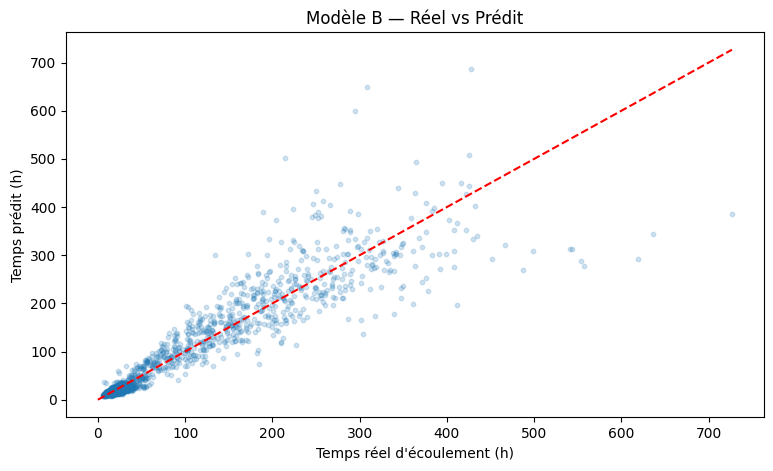

In [8]:
plt.scatter(y_test_r, pred_r, alpha=0.2, s=10)
plt.plot([0, y_test_r.max()], [0, y_test_r.max()], color="red", linestyle="--")
plt.xlabel("Temps réel d'écoulement (h)")
plt.ylabel("Temps prédit (h)")
plt.title("Modèle B — Réel vs Prédit")
plt.show()

## 5. Importance des variables

Comprendre quels paramètres pèsent le plus dans la décision d'écoulement — utile pour affiner
la collecte de données et pour expliquer le modèle aux partenaires/investisseurs.

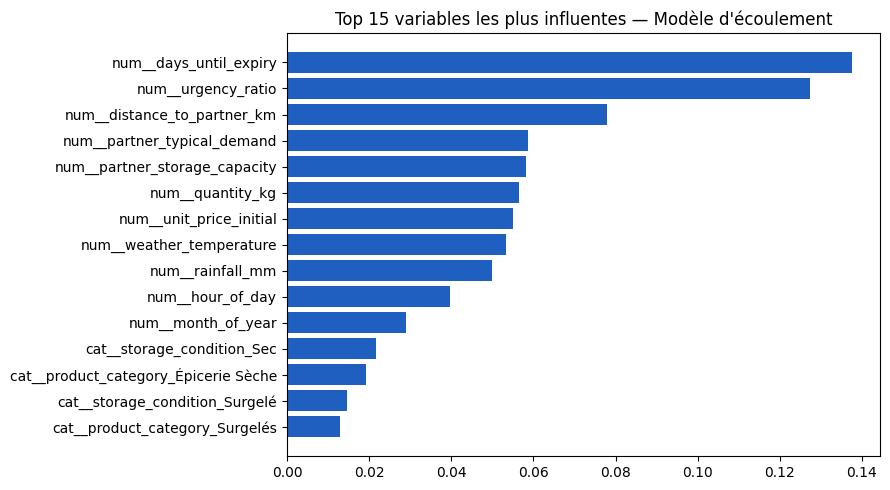

In [9]:
importances = clf_pipeline.named_steps["model"].feature_importances_
feature_names = clf_pipeline.named_steps["prep"].get_feature_names_out()

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#1f5fbf")
plt.title("Top 15 variables les plus influentes — Modèle d'écoulement")
plt.tight_layout()
plt.show()

## 6. Prévision de volume d'invendus par catégorie — horizon 6 mois

Objectif business : anticiper, catégorie par catégorie, le **volume d'invendus attendu sur les
6 prochains mois** afin de dimensionner les partenariats (Socofrais, Dabali Express, etc.) et la
capacité de collecte à l'avance.

Approche : agrégation mensuelle du volume (`quantity_kg`) par catégorie, puis régression sur les
composantes temporelles (mois, tendance, saison) — équivalent simplifié d'un modèle Prophet.

In [10]:
monthly = (
    df.groupby([pd.Grouper(key="collection_datetime", freq="MS"), "product_category"])["quantity_kg"]
    .sum()
    .reset_index()
    .rename(columns={"collection_datetime": "month", "quantity_kg": "total_kg"})
)
monthly["month_index"] = (monthly["month"].dt.year - monthly["month"].dt.year.min()) * 12 + monthly["month"].dt.month
monthly["month_num"] = monthly["month"].dt.month
monthly.head()

,month,product_category,total_kg,month_index,month_num
0,2024-01-01,Boulangerie,3289.8,1,1
1,2024-01-01,Fruits & Légumes,8063.8,1,1
2,2024-01-01,Produits Laitiers,3974.1,1,1
3,2024-01-01,Surgelés,3758.7,1,1
4,2024-01-01,Viande & Poisson,3353.3,1,1


In [11]:
def forecast_category(cat_df, horizon_months=6):
    """Régression simple : tendance linéaire + saisonnalité mensuelle (dummies)."""
    cat_df = cat_df.sort_values("month_index").copy()
    X = pd.get_dummies(cat_df["month_num"], prefix="m")
    X["trend"] = cat_df["month_index"]
    y = cat_df["total_kg"]

    model = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
    model.fit(X, y)

    last_index = cat_df["month_index"].max()
    last_month_num = cat_df.loc[cat_df["month_index"] == last_index, "month_num"].iloc[0]

    future_rows = []
    for h in range(1, horizon_months + 1):
        fut_index = last_index + h
        fut_month_num = ((last_month_num - 1 + h) % 12) + 1
        future_rows.append({"month_index": fut_index, "month_num": fut_month_num})

    future_df = pd.DataFrame(future_rows)
    X_future = pd.get_dummies(future_df["month_num"], prefix="m")
    X_future["trend"] = future_df["month_index"]
    X_future = X_future.reindex(columns=X.columns, fill_value=0)

    future_df["predicted_kg"] = model.predict(X_future)
    return future_df

forecasts = {}
for cat in df["product_category"].unique():
    cat_df = monthly[monthly["product_category"] == cat]
    forecasts[cat] = forecast_category(cat_df, horizon_months=6)

for cat, f in forecasts.items():
    print(f"\n{cat} — prévision des 6 prochains mois (kg) :")
    print(f[["month_index", "predicted_kg"]].round(1).to_string(index=False))


Boulangerie — prévision des 6 prochains mois (kg) :
 month_index  predicted_kg
          19        3668.8
          20        3661.6
          21        4234.9
          22        3515.2
          23        3617.2
          24        3874.8

Produits Laitiers — prévision des 6 prochains mois (kg) :
 month_index  predicted_kg
          19        4342.4
          20        3938.7
          21        4317.9
          22        4398.5
          23        4338.3
          24        3879.6

Fruits & Légumes — prévision des 6 prochains mois (kg) :
 month_index  predicted_kg
          19        7161.5
          20        7890.7
          21        8100.4
          22        7639.1
          23        7573.4
          24        7229.4

Viande & Poisson — prévision des 6 prochains mois (kg) :
 month_index  predicted_kg
          19        3657.0
          20        3638.1
          21        3626.8
          22        3766.4
          23        3629.2
          24        3823.1

Épicerie Sèche 

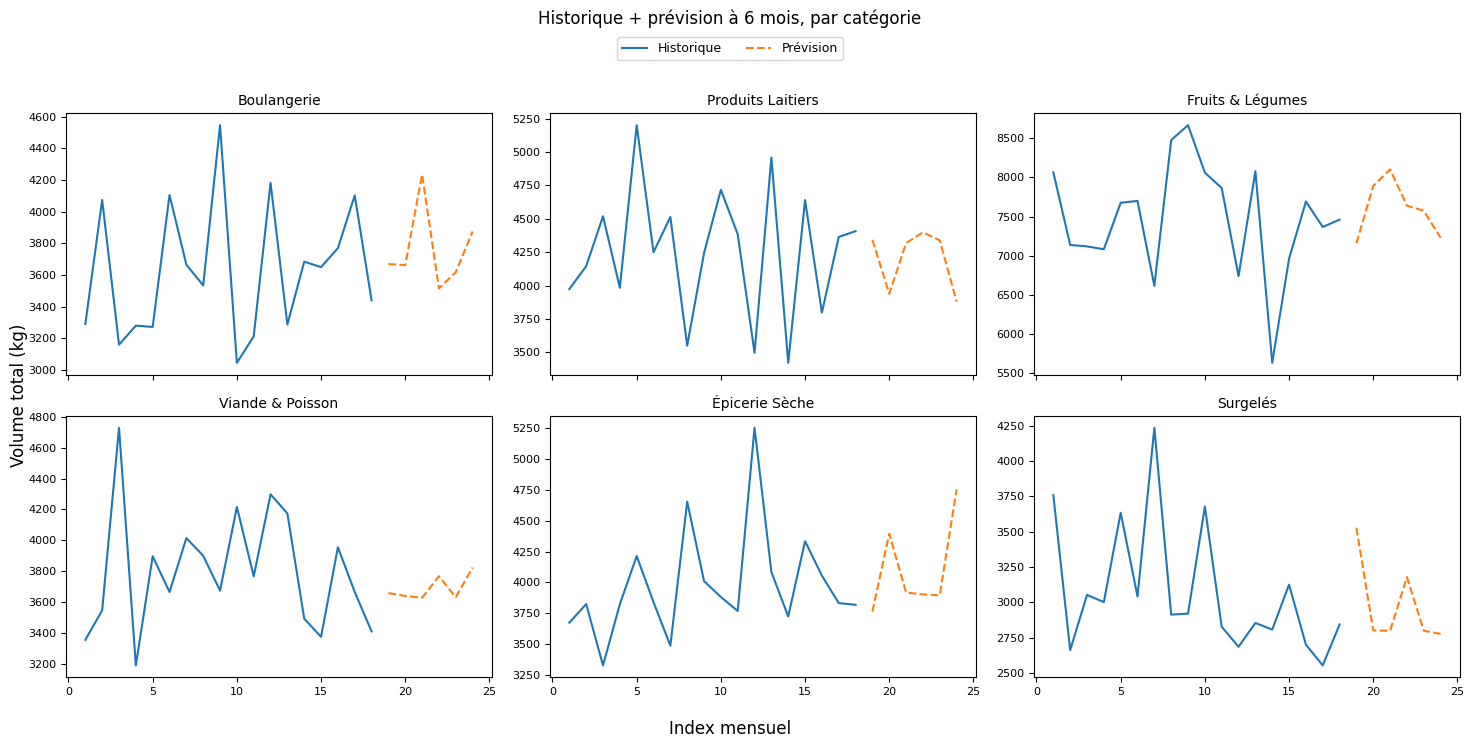

In [20]:
n_cats = len(forecasts)
n_cols = 3
n_rows = -(-n_cats // n_cols)  # arrondi supérieur

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), sharex=True, sharey=False)
axes = axes.flatten()

for i, (cat, f) in enumerate(forecasts.items()):
    ax = axes[i]
    hist = monthly[monthly["product_category"] == cat]
    ax.plot(hist["month_index"], hist["total_kg"], color="tab:blue", label="Historique")
    ax.plot(f["month_index"], f["predicted_kg"], linestyle="--", color="tab:orange", label="Prévision")
    ax.set_title(cat, fontsize=10)
    ax.tick_params(labelsize=8)

# Masquer les axes vides s'il y a plus de cases que de catégories
for j in range(n_cats, len(axes)):
    axes[j].axis("off")

# Légende commune en haut
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, 1.02))

fig.supxlabel("Index mensuel")
fig.supylabel("Volume total (kg)")
fig.suptitle("Historique + prévision à 6 mois, par catégorie", y=1.05)
plt.tight_layout()
plt.show()

## 7. Priorisation du stock à écouler (aide au matching)

Fonction simple combinant :
- la probabilité d'écoulement prédite par le Modèle A,
- l'urgence (DLC restante),

pour produire un **score de priorité** par lot — utilisé par la plateforme pour ordonner les
lots à proposer en premier aux partenaires.

In [13]:
def compute_priority_score(row_df):
    proba_sold = clf_pipeline.predict_proba(row_df[FEATURES])[:, 1]
    urgency = 1 / (row_df["days_until_expiry"] + 1)
    # Score : on priorise les lots urgents ET à forte probabilité d'être repris rapidement
    score = 0.6 * urgency + 0.4 * proba_sold
    return score

sample = df.sample(10, random_state=1).copy()
sample["priority_score"] = compute_priority_score(sample)
sample[["product_category", "days_until_expiry", "priority_score"]].sort_values(
    "priority_score", ascending=False
)

,product_category,days_until_expiry,priority_score
4253,Fruits & Légumes,1,0.459961
2145,Produits Laitiers,1,0.436279
10509,Produits Laitiers,5,0.429325
13684,Épicerie Sèche,5,0.428908
1622,Viande & Poisson,2,0.411915
5150,Fruits & Légumes,2,0.411646
6900,Viande & Poisson,2,0.410076
9296,Produits Laitiers,2,0.381746
7576,Surgelés,48,0.354333
506,Épicerie Sèche,31,0.250934


## 8. Export des modèles pour intégration à la plateforme

On sauvegarde les pipelines entraînés avec `joblib`. Le backend de la plateforme (ex: FastAPI)
pourra les charger directement pour scorer un nouveau lot en temps réel.

In [14]:
joblib.dump(clf_pipeline, "model_probabilite_ecoulement.joblib")
joblib.dump(reg_pipeline, "model_temps_ecoulement.joblib")
print("Modèles sauvegardés : model_probabilite_ecoulement.joblib, model_temps_ecoulement.joblib")

Modèles sauvegardés : model_probabilite_ecoulement.joblib, model_temps_ecoulement.joblib


## 9. Exemple d'inférence (utilisation en production)

Ci-dessous, la fonction telle qu'elle serait appelée par l'API de la plateforme lorsqu'un nouveau
lot est enregistré après collecte.

In [15]:
def predict_new_lot(lot: dict) -> dict:
    """
    lot : dictionnaire avec les mêmes clés que FEATURES
    Retourne la probabilité d'écoulement, le temps estimé, et un score de priorité.
    """
    row = pd.DataFrame([lot])[FEATURES]
    proba = clf_pipeline.predict_proba(row)[0, 1]
    temps_estime = reg_pipeline.predict(row)[0]
    urgency = 1 / (lot["days_until_expiry"] + 1)
    priority = 0.6 * urgency + 0.4 * proba
    return {
        "probabilite_ecoulement": round(float(proba), 3),
        "temps_estime_heures": round(float(temps_estime), 1),
        "score_priorite": round(float(priority), 3),
    }

exemple_lot = {
    "product_category": "Fruits & Légumes", "product_subcategory": "Agrumes",
    "storage_condition": "Frais", "packaging_type": "Carton", "pickup_city": "Abidjan",
    "day_of_week": "Friday", "season": "Pluies",
    "quantity_kg": 80, "unit_price_initial": 1.3, "days_until_expiry": 2, "is_holiday": 0,
    "distance_to_partner_km": 8.5, "partner_storage_capacity": 500, "partner_typical_demand": 300,
    "weather_temperature": 29.5, "rainfall_mm": 3.2, "month_of_year": 7, "hour_of_day": 14,
    "is_weekend": 0, "urgency_ratio": 0.5,
}

predict_new_lot(exemple_lot)

{'probabilite_ecoulement': 0.682,
 'temps_estime_heures': 25.2,
 'score_priorite': 0.473}

## Résumé

- **Modèle A (classification)** : prédit la probabilité qu'un lot soit effectivement écoulé — sert à
  alerter tôt sur les lots à risque et à décider d'une remise plus agressive.
- **Modèle B (régression)** : estime le temps d'écoulement — utile pour le SLA de matching.
- **Prévision par catégorie (6 mois)** : pilotage stratégique — anticiper les volumes pour dimensionner
  les partenariats commerciaux et les tournées de collecte.
- **Score de priorité** : fonction combinée directement branchable sur l'algorithme de matching de
  la plateforme.

**Prochaine étape recommandée** : dès que des données réelles remplacent le dataset synthétique
(après quelques mois de pilote), ré-entraîner ces mêmes pipelines — l'architecture ne change pas.